## Aspect-Based Sentiment Analysis Comparison
### **Course:** Applied Computer Science – Data & AI 6
### **Team:** Vladalin Bosii, Aleksiya Solovyova
##### **Date:** 2025-10-13
This notebook compares three different ABSA implementations:
- **Lexicon-based (spaCy + VADER)**
- **Transformer-based (Pretrained ABSA model)**
- **LLM-based (Ollama local LLM)**

We run all three on a subset of the Yelp Reviews dataset (~1000 samples),
then compare performance, accuracy, and qualitative behavior.

In [1]:
import pandas as pd
from datasets import load_dataset
from IPython.display import display
from tqdm import tqdm
import matplotlib.pyplot as plt

from src.lexicon_absa import LexiconABSAAnalyzer
from src.transformer_absa import TransformerABSA
from src.llm_absa import LLMABSA

In [2]:
ds= load_dataset("Yelp/yelp_review_full", split="train[:10]")
yelp_reviews = ds.to_pandas()

yelp_reviews.rename(columns={"text":"review_text", "label":"rating"}, inplace=True)
display(yelp_reviews.head())

,rating,review_text
0,4,dr. goldberg offers everything i look for in a...
1,1,"Unfortunately, the frustration of being Dr. Go..."
2,3,Been going to Dr. Goldberg for over 10 years. ...
3,3,Got a letter in the mail last week that said D...
4,0,I don't know what Dr. Goldberg was like before...


In [3]:
lexicon_analyzer = LexiconABSAAnalyzer()
transformer_analyzer = TransformerABSA()
llm_analyzer = LLMABSA(model_name="llama3.1:8b")

analyzers = {
    "Lexicon": lexicon_analyzer,
    "Transformer": transformer_analyzer,
    "LLM": llm_analyzer
}

Loading transformer model: yangheng/deberta-v3-base-absa-v1.1...


/home/aleks/PycharmProjects/data6team28/.venv/lib/python3.12/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Model 'yangheng/deberta-v3-base-absa-v1.1' loaded successfully.
Using model 'llama3.1:8b'...
✓ Model 'llama3.1:8b' is available.


In [4]:
results = []
for model_name, analyzer in analyzers.items():
    print(f"\nRunning {model_name} Analyzer")
    for idx, row in tqdm(yelp_reviews.iterrows(), total=len(yelp_reviews), desc=f"{model_name}"):
        text = row["review_text"]

        try:
            aspects = analyzer.analyze(text)
            for asp in aspects:
                results.append({
                    "review_id": idx,
                    "model": model_name,
                    "aspect": asp.aspect,
                    "sentiment": asp.sentiment,
                    "confidence": asp.confidence,
                    "review_text": text
                })
        except Exception as e:
            print(f"Error on review {idx} ({model_name}): {e}")
            continue

results_df = pd.DataFrame(results)
display(results_df.head())


Running Lexicon Analyzer


Lexicon: 100%|██████████| 10/10 [00:00<00:00, 14.10it/s]



Running Transformer Analyzer


Transformer: 100%|██████████| 10/10 [00:11<00:00,  1.10s/it]



Running LLM Analyzer


LLM: 100%|██████████| 10/10 [09:26<00:00, 56.67s/it]


,review_id,model,aspect,sentiment,confidence,review_text
0,0,Lexicon,practitioner,neutral,0.0000,dr. goldberg offers everything i look for in a...
1,0,Lexicon,notch,positive,0.2023,dr. goldberg offers everything i look for in a...
2,1,Lexicon,doctor,neutral,0.0000,"Unfortunately, the frustration of being Dr. Go..."
3,1,Lexicon,staff,negative,0.4767,"Unfortunately, the frustration of being Dr. Go..."
4,1,Lexicon,need,neutral,0.0000,"Unfortunately, the frustration of being Dr. Go..."


model
LLM            53
Lexicon        40
Transformer    50
Name: aspect, dtype: int64

sentiment,negative,neutral,positive
model,,,
LLM,21,10,22
Lexicon,5,24,11
Transformer,18,6,26


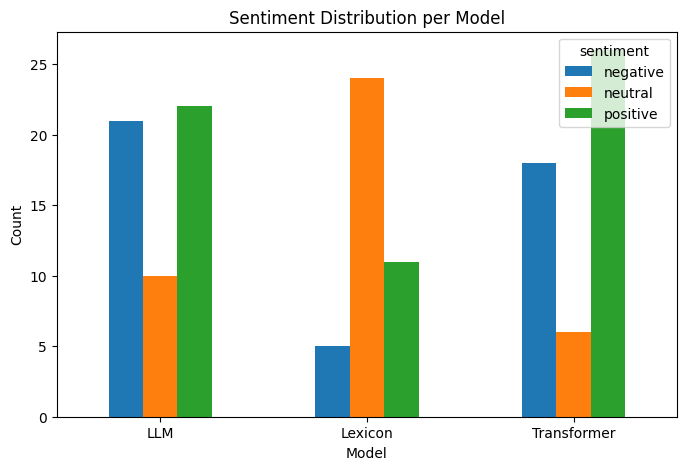

In [5]:
aspect_counts = results_df.groupby("model")["aspect"].count()
display(aspect_counts)

sentiment_dist = results_df.groupby(["model", "sentiment"]).size().unstack(fill_value=0)
display(sentiment_dist)

sentiment_dist.plot(kind="bar", figsize=(8, 5), title="Sentiment Distribution per Model")
plt.xlabel("Model")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [6]:
#finding reviews where the models disagree
pivot_df = results_df.pivot_table(
    index=["review_id", "aspect"],
    columns="model",
    values="sentiment",
    aggfunc=lambda x: list(x)[0] if len(x) > 0 else None
).reset_index()
disagreements = pivot_df[
    pivot_df.nunique(axis=1) > 3
].merge(yelp_reviews, left_on="review_id", right_index=True)
display(disagreements.head(40))

,review_id,aspect,LLM,Lexicon,Transformer,rating,review_text
77,6,doctor,positive,neutral,positive,4,Dr. Eric Goldberg is a fantastic doctor who ha...
112,8,sauce,NaN,neutral,negative,1,Wing sauce is like water. Pretty much a lot of...
116,8,wing,NaN,neutral,negative,1,Wing sauce is like water. Pretty much a lot of...
127,9,range,positive,neutral,positive,2,Decent range somewhat close to the city. The ...
